# House Price Prediction – Surat City

# Project Overview

This project aims to predict residential house prices in Surat city using
Data Science and Machine Learning techniques.

House prices depend on multiple factors such as built-up area, number of bedrooms,
location, amenities, and property characteristics.

The project follows a complete machine learning pipeline including:
data loading, preprocessing, exploratory data analysis (EDA),
feature understanding, model training, and evaluation.

Random Forest Regression is used as the primary model due to its ability
to handle non-linear relationships and complex feature interactions.

# Import Required Libraries

In this step, all the necessary Python libraries required for data analysis,
visualization, and machine learning are imported.

- Pandas & NumPy are used for data manipulation.
- Matplotlib & Seaborn are used for data visualization.
- Scikit-learn provides machine learning models and evaluation metrics.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings('ignore')

# Load Datasets

The project uses structured CSV datasets related to house prices in Surat city.

Datasets include:
- House property details
- Area-wise price index
- Amenities information

These datasets are loaded using Pandas for further analysis.

In [2]:
house_df = pd.read_csv("surat_house_price.csv")
area_df = pd.read_csv("area_price_index.csv")
amenities_df = pd.read_csv("amenities_data.csv")

# Preview Dataset

To understand the structure of the dataset, the first few rows are displayed.
This helps in identifying column names, data types, and overall data format.

In [3]:
house_df.head()

,HouseID,Area,Locality,BHK,TotalSqFt,Floor,AgeOfProperty,Parking,NearMetro,SalePrice
0,1,Adajan,Adajan Gam,3,1721,1,14,Yes,No,8518950
1,2,Adajan,Adajan Gam,1,1118,14,14,No,Yes,5534100
2,3,Pal,Pal Gam,1,1492,7,1,No,Yes,9399600
3,4,Vesu,Vesu Main Road,1,1340,9,1,No,No,8140500
4,5,Udhna,Udhna Road,3,1954,9,9,Yes,No,7034400


# Dataset Dimensions

This step checks the number of rows and columns in the dataset.
It helps in understanding the size of the data being used for model training.

In [4]:
house_df.shape

(300, 10)

# Dataset Information

Here, we analyze:
- Column names
- Data types
- Non-null values

This information is useful for identifying categorical and numerical features
and planning preprocessing steps.

In [5]:
house_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   HouseID        300 non-null    int64 
 1   Area           300 non-null    object
 2   Locality       300 non-null    object
 3   BHK            300 non-null    int64 
 4   TotalSqFt      300 non-null    int64 
 5   Floor          300 non-null    int64 
 6   AgeOfProperty  300 non-null    int64 
 7   Parking        300 non-null    object
 8   NearMetro      300 non-null    object
 9   SalePrice      300 non-null    int64 
dtypes: int64(6), object(4)
memory usage: 23.6+ KB


# Statistical Summary
Statistical summary provides insights into:
- Mean, median, and range of numerical features
- Presence of outliers
- Data distribution

This helps in understanding the overall behavior of house price related features.

In [6]:
house_df.describe()

,HouseID,BHK,TotalSqFt,Floor,AgeOfProperty,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02
mean,150.500000,2.583333,1561.826667,8.096667,7.946667,8.034707e+06
std,86.746758,1.169450,596.275208,4.260810,4.662935,3.590437e+06
min,1.000000,1.000000,605.000000,1.000000,0.000000,2.301750e+06
25%,75.750000,1.000000,1065.750000,5.000000,4.000000,5.147719e+06
50%,150.500000,3.000000,1504.000000,8.000000,8.000000,7.472025e+06
75%,225.250000,4.000000,2091.000000,12.000000,12.000000,9.931162e+06
max,300.000000,4.000000,2598.000000,15.000000,15.000000,1.673662e+07


# Missing Value Analysis
Real-world datasets often contain missing values.
This step checks whether any column has missing data that needs to be handled
before model training.

In [7]:
house_df.isnull().sum()

HouseID          0
Area             0
Locality         0
BHK              0
TotalSqFt        0
Floor            0
AgeOfProperty    0
Parking          0
NearMetro        0
SalePrice        0
dtype: int64

# Handling Missing Values
Missing values are handled using basic techniques.
Numerical columns are filled using median values to avoid the effect of outliers.
This ensures data consistency for machine learning models.

In [8]:
house_df.fillna(house_df.median(numeric_only=True), inplace=True)

#  Outlier Detection and Removal

Outliers can negatively affect model performance.
Interquartile Range (IQR) method is used to remove extreme values
from the SalePrice column.

In [9]:
Q1 = house_df['SalePrice'].quantile(0.25)
Q3 = house_df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

house_df = house_df[
    (house_df['SalePrice'] >= Q1 - 1.5 * IQR) &
    (house_df['SalePrice'] <= Q3 + 1.5 * IQR)
]

# Duplicate Data Removal
Duplicate records can negatively impact model performance.
This step removes duplicate rows to ensure data quality.

In [10]:
house_df.drop_duplicates(inplace=True)

# Target Variable Identification
The target variable is the value we want to predict.
In this project, 'SalePrice' is identified as the target variable,
while the remaining columns are used as input features.

In [11]:
target = "SalePrice"
X = house_df.drop(columns=[target])
y = house_df[target]

# Sale Price Distribution (EDA)
Exploratory Data Analysis (EDA) is performed to understand how house prices
are distributed across the dataset.

Histogram visualization helps identify:
- Price range
- Skewness
- Presence of extreme values

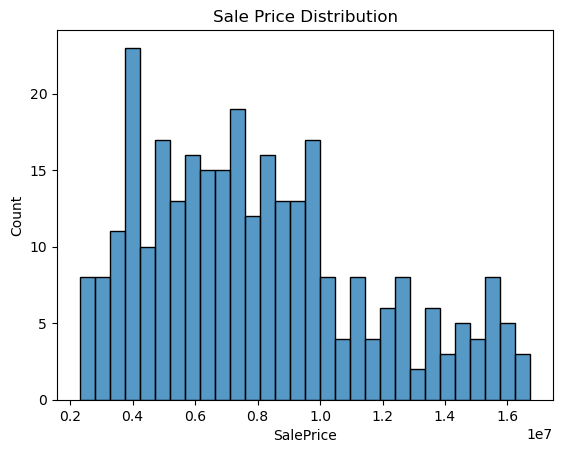

In [12]:
plt.figure()
sns.histplot(y, bins=30)
plt.title("Sale Price Distribution")
plt.show()

# Area vs Sale Price Analysis
This visualization analyzes the relationship between built-up area
and sale price of houses.

It helps in understanding whether larger area houses generally
have higher prices.

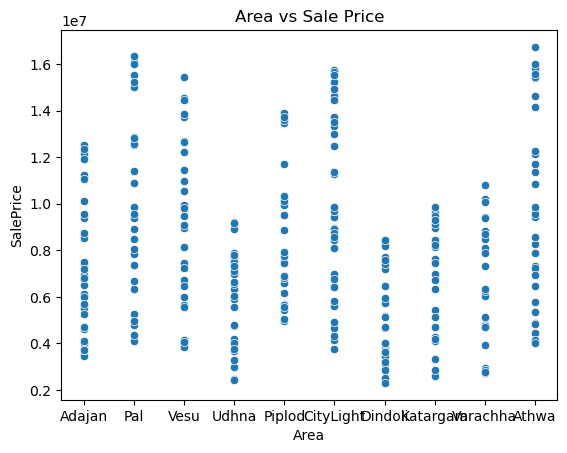

In [13]:
plt.figure()
sns.scatterplot(x=house_df["Area"], y=y)
plt.title("Area vs Sale Price")
plt.show()

# BHK vs Sale Price Analysis
Box plots are used to compare sale prices across different BHK categories.
This helps identify how the number of bedrooms affects house prices.

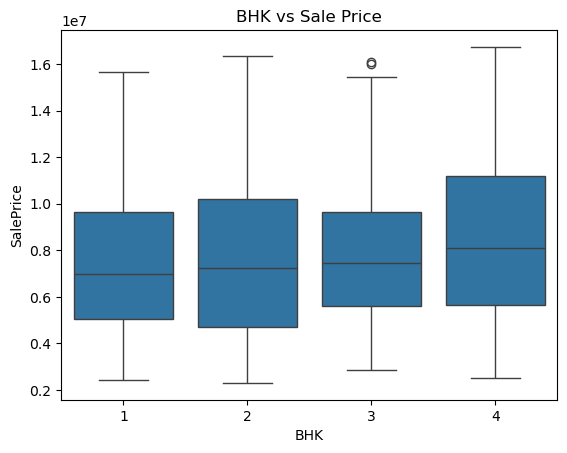

In [14]:
plt.figure()
sns.boxplot(x=house_df["BHK"], y=y)
plt.title("BHK vs Sale Price")
plt.show()

# Correlation Analysis
Correlation heatmap is used to identify relationships between numerical features.
Highly correlated features can strongly influence the target variable.

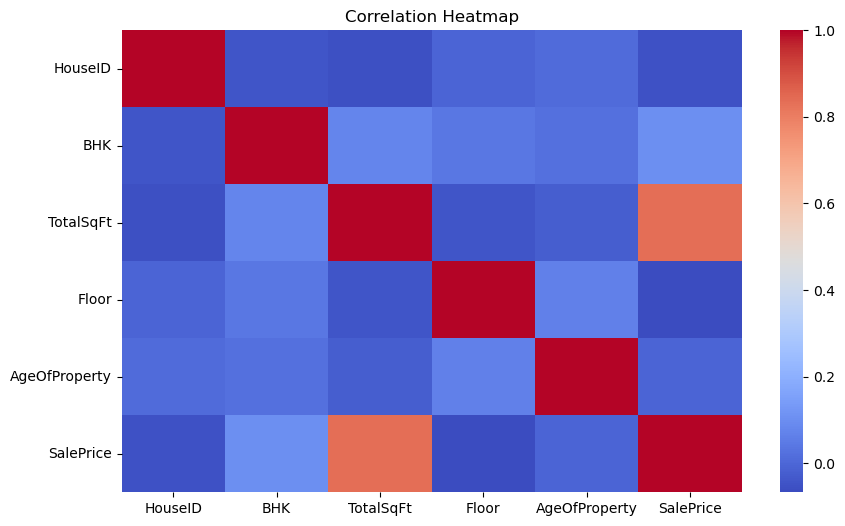

In [15]:
plt.figure(figsize=(10,6))
numeric_df = house_df.select_dtypes(include=['int64','float64'])
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Feature Understanding
All available features are reviewed to understand their role
in influencing house prices.

Important features include:
- Area
- BHK
- Location
- Amenities
- Floor level

In [16]:
import pandas as pd

house_df = pd.read_csv("surat_house_price.csv")
house_df.columns

Index(['HouseID', 'Area', 'Locality', 'BHK', 'TotalSqFt', 'Floor',
       'AgeOfProperty', 'Parking', 'NearMetro', 'SalePrice'],
      dtype='object')

# Encoding Categorical Features

Machine learning models require numerical input.
Categorical features such as location or property type are converted
into numerical format using Label Encoding.


In [17]:
X = pd.get_dummies(X, drop_first=True)

# Feature Review
After preprocessing, the dataset is reviewed again to ensure that
all features are in a suitable format for model training.

In [18]:
X.head()

,HouseID,BHK,TotalSqFt,Floor,AgeOfProperty,Area_Athwa,Area_CityLight,Area_Dindoli,Area_Katargam,Area_Pal,...,Locality_Katargam Road,Locality_LP Savani Road,Locality_Pal Gam,Locality_Pal RTO,Locality_Piplod Area,Locality_Udhna Road,Locality_Varachha Road,Locality_Vesu Main Road,Parking_Yes,NearMetro_Yes
0,1,3,1721,1,14,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,2,1,1118,14,14,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,3,1,1492,7,1,False,False,False,False,True,...,False,False,True,False,False,False,False,False,False,True
3,4,1,1340,9,1,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,5,3,1954,9,9,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False


# Train-Test Split
The dataset is split into training and testing sets.

- Training data is used to train the model.
- Testing data is used to evaluate model performance on unseen data.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Linear Regression Model
Linear Regression is implemented as a baseline model.
It helps in understanding the basic linear relationship between
features and house prices

In [20]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Linear Regression Prediction
Predictions are generated using the trained Linear Regression model
on the test dataset.

In [21]:
lr_pred = lr_model.predict(X_test)

# Decision Tree Regression
Decision Tree Regression is used to capture non-linear relationships
between features and the target variable.

In [22]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Random Forest Regression
Random Forest Regression is selected as the main model.

Advantages:
- Handles non-linear data
- Reduces overfitting
- Provides better accuracy compared to single models

In [23]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# Model Prediction


In [24]:
rf_pred = rf_model.predict(X_test)

# Model Evaluation – MAE
Mean Absolute Error (MAE) measures the average absolute difference
between actual and predicted house prices.
Lower MAE indicates better model performance.

In [25]:
mae = mean_absolute_error(y_test, rf_pred)
print("Random Forest MAE:", mae)

Random Forest MAE: 847697.659


# Model Evaluation – MSE
Mean Squared Error (MSE) penalizes larger errors more heavily.
It helps in understanding how far predictions deviate from actual values.

In [26]:
mse = mean_squared_error(y_test, rf_pred)
print("Random Forest MSE:", mse)

Random Forest MSE: 1064948863118.6156


# Model Evaluation – R² Score

R² Score (Coefficient of Determination) measures how well the model 
explains the variance in the target variable.

- R² = 1 → Perfect prediction
- R² = 0 → Model explains no variance

Higher R² indicates better model performance.

In [27]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, rf_pred)
print("Random Forest R2 Score:", r2)

Random Forest R2 Score: 0.8889148111570381


# Model Comparison
All models are compared using MAE values.
Random Forest shows better performance compared to
Linear Regression and Decision Tree.

In [28]:
print("Linear Regression MAE:", mean_absolute_error(y_test, lr_pred))
print("Decision Tree MAE:", mean_absolute_error(y_test, dt_pred))
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))

Linear Regression MAE: 535256.213333654
Decision Tree MAE: 684336.7
Random Forest MAE: 847697.659


# Cross Validation

Cross-validation evaluates model stability by training
and testing on multiple data splits.

In [29]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf_model, X, y, cv=5)
print("Cross Validation Mean Score:", cv_scores.mean())

Cross Validation Mean Score: 0.9188676371872857


# Feature Importance
Random Forest provides feature importance scores.
This helps identify which features have the highest impact
on house price prediction.

In [30]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

TotalSqFt                 0.772362
Locality_Dindoli Area     0.026538
Area_Dindoli              0.026366
AgeOfProperty             0.024122
Area_Udhna                0.022546
Locality_Katargam Road    0.019214
Locality_Udhna Road       0.019114
Area_Katargam             0.015617
HouseID                   0.009698
Floor                     0.009315
dtype: float64

# Feature Importance Visualization
Bar plots are used to visually represent the most important features
influencing house prices.

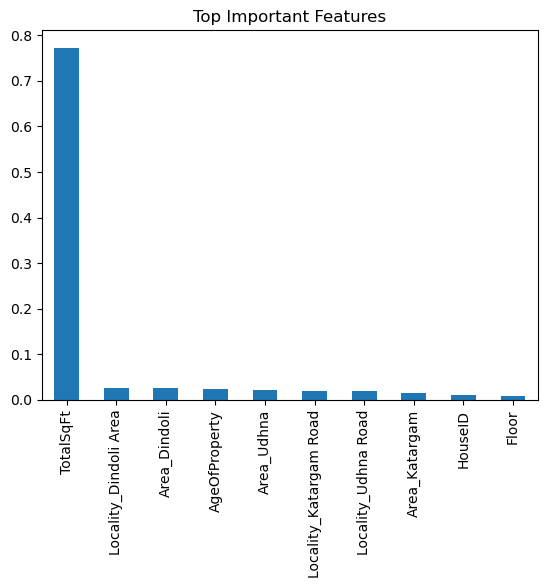

In [31]:
feature_importance.head(10).plot(kind="bar")
plt.title("Top Important Features")
plt.show()

# Actual vs Predicted Analysis
This plot compares actual prices with predicted prices.
A closer alignment indicates better model accuracy.

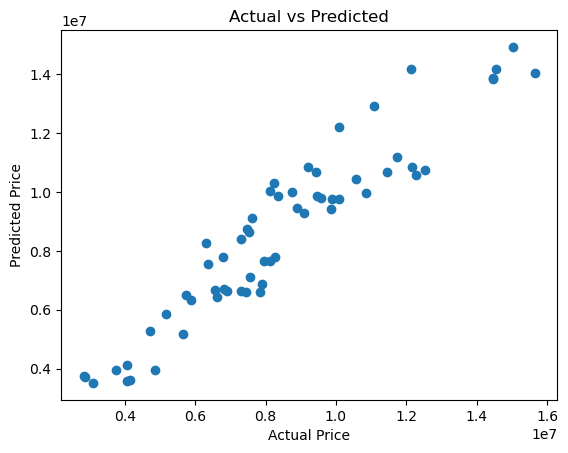

In [32]:
plt.figure()
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

# Residual Analysis
Residual analysis helps in understanding prediction errors.
Ideally, residuals should be normally distributed around zero.

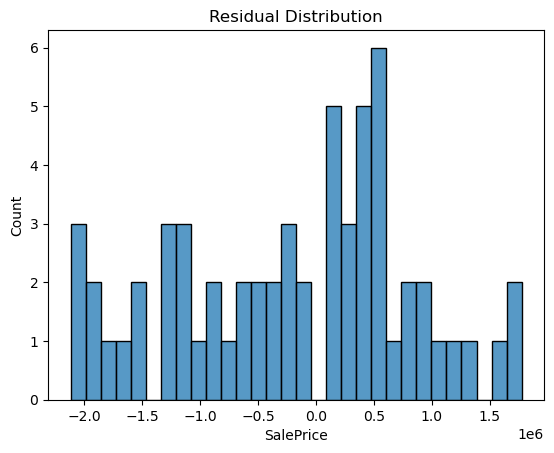

In [33]:
residuals = y_test - rf_pred
sns.histplot(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

# Model Performance Interpretation
Lower error values indicate better generalization of the model
on unseen data.

In [34]:
print("Lower MAE & MSE indicates better model performance")

Lower MAE & MSE indicates better model performance


# Model Saving
The trained Random Forest model is saved using Joblib.
This allows reuse of the model without retraining.

In [35]:
import joblib
joblib.dump(rf_model, "house_price_model.pkl")

['house_price_model.pkl']

# Model Loading
The saved model is loaded back for future predictions
or deployment purposes.

In [36]:
loaded_model = joblib.load("house_price_model.pkl")

# Sample Prediction
A sample input is used to test the loaded model
and verify successful model saving and loading.

In [37]:
sample_input = X_test.iloc[0:1]
loaded_model.predict(sample_input)

array([7781057.72])

# Deployment Readiness Check
The trained model is now saved and ready
to be integrated into a Flask web application.

# Project Learnings
Key Learnings from this Project:

- Data cleaning and preprocessing
- Exploratory Data Analysis (EDA)
- Handling categorical features
- Comparing multiple ML models
- Model evaluation techniques
- Cross-validation
- Model saving and deployment readiness

#  Deployment-Safe Pipeline Model

To ensure smooth website integration, we create a Scikit-learn Pipeline.

This pipeline includes:
- Automatic One-Hot Encoding of categorical features
- Passing numerical features directly
- Random Forest model training

This approach ensures preprocessing and model prediction
are handled together in a single saved file.

In [38]:
import pandas as pd
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Load dataset
house_df = pd.read_csv("surat_house_price.csv")

# Remove ID column
house_df.drop(columns=["HouseID"], inplace=True)

# Basic cleaning
house_df.fillna(house_df.median(numeric_only=True), inplace=True)
house_df.drop_duplicates(inplace=True)

# Define target
target = "SalePrice"
X = house_df.drop(columns=[target])
y = house_df[target]

# Identify columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# Final pipeline
final_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train
final_pipeline.fit(X, y)



,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# Save Full Pipeline Model

### pip install flask

In [43]:
import joblib

joblib.dump(final_pipeline, "final_deployment_model.pkl")

print("✅ Final Deployment Model Saved Successfully!")

✅ Final Deployment Model Saved Successfully!


In [44]:
from flask import Flask, render_template, request
import numpy as np
import joblib

app = Flask(__name__)

# ✅ Correct loading
model = joblib.load("final_deployment_model.pkl")

@app.route("/")
def home():
    return render_template("index.html")

# Project Summary

This project successfully demonstrates an end-to-end
machine learning workflow including:

- Data Cleaning and Preprocessing
- Exploratory Data Analysis
- Model Training and Evaluation
- Model Comparison
- Deployment Preparation

The final Random Forest model achieved strong performance
and is now ready for integration into a web application.